# Preparación de Gold: inteligencia de columnas, calidad y estrategia de unión

Este notebook sigue una lectura ejecutiva. Cada bloque abre con lo que se va a revisar, continúa con el análisis y cierra con una interpretación concreta para decidir qué columnas conservar, cuáles limpiar y qué entidades conviene unir.

El objetivo es convertir la exploración en una decisión de diseño: Bronze aporta la materia prima, Silver muestra el grano real de los registros y el cierre deja definida la base para Gold.

In [15]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
NOTEBOOK_OUTPUT = PROJECT_ROOT / 'notebooks' / 'output'
BRONZE_EDA_CSV = NOTEBOOK_OUTPUT / 'bronze_twitter_eda.csv'
SILVER_EDA_CSV = NOTEBOOK_OUTPUT / 'silver_eda.csv'

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'BRONZE_EDA_CSV = {BRONZE_EDA_CSV}')
print(f'SILVER_EDA_CSV = {SILVER_EDA_CSV}')

PROJECT_ROOT = /home/naciscric/Documents/university/2026-1/Data-Analysis-Programming
BRONZE_EDA_CSV = /home/naciscric/Documents/university/2026-1/Data-Analysis-Programming/notebooks/output/bronze_twitter_eda.csv
SILVER_EDA_CSV = /home/naciscric/Documents/university/2026-1/Data-Analysis-Programming/notebooks/output/silver_eda.csv


In [16]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return pd.read_csv(path)

def preview_frame(df: pd.DataFrame, title: str, max_rows: int = 5) -> None:
    display(Markdown(f'## {title}'))
    display(pd.DataFrame({'rows': [len(df)], 'columns': [len(df.columns)]}))
    display(df.head(max_rows))

def audit_frame(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_ratio': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
        'nunique': [df[col].nunique(dropna=True) for col in df.columns],
    }).sort_values(['missing_ratio', 'column'], ascending=[False, True])

def summarize_numeric(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include='number')
    if numeric_cols.empty:
        return pd.DataFrame()
    return numeric_cols.describe().T

def top_values(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame()
    return df[column].value_counts(dropna=False).head(n).to_frame('rows')

def candidate_columns(df: pd.DataFrame, max_missing: float = 0.35) -> list[str]:
    audit = audit_frame(df)
    keep = audit.loc[audit['missing_ratio'] <= max_missing, 'column'].tolist()
    return keep

## 1. Bronze: alcance y criterio de revisión

- **Qué analiza:** texto original, autor, fecha, idioma y señales de interacción.
- **Por qué importa:** aquí se define la base real para sentimiento, percepción y series de tiempo.
- **Objetivo ejecutivo:** separar señales analíticas de metadata operativa antes de construir Gold.

In [17]:
bronze_df = load_csv(BRONZE_EDA_CSV)
preview_frame(bronze_df, 'Bronze CSV')
display(audit_frame(bronze_df).head(40))
display(summarize_numeric(bronze_df))

## Bronze CSV

,rows,columns
0,300,8


,tweet_text,tweet_lang,tweet_text_raw,clean_text,text_length,detected_lang,is_english,lang_match
0,@Bose 1/ Really disappointed with Bose ending cloud support for the SoundTouch 20.\n\nI bought this as a premium con...,en,@Bose 1/ Really disappointed with Bose ending cloud support for the SoundTouch 20.\n\nI bought this as a premium con...,1/ Really disappointed with Bose ending cloud support for the SoundTouch 20. I bought this as a premium connected sp...,266,en,True,True
1,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",en,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...","I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",1064,en,True,True
2,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",en,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...","I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",1064,en,True,True
3,"Ever forget you’re wearing earbuds until the battery dies? We tested the Sony LinkBuds Fit through workouts, errands...",en,"Ever forget you’re wearing earbuds until the battery dies? We tested the Sony LinkBuds Fit through workouts, errands...","Ever forget you’re wearing earbuds until the battery dies? We tested the Sony LinkBuds Fit through workouts, errands...",142,en,True,True
4,"Dashy talks about Mercules' camera falling on main stage 😂🗣️\n\nDashy : ""I got new sound proof earbuds, I can't hear...",en,"Dashy talks about Mercules' camera falling on main stage 😂🗣️\n\nDashy : ""I got new sound proof earbuds, I can't hear...","Dashy talks about Mercules' camera falling on main stage 😂🗣️ Dashy : ""I got new sound proof earbuds, I can't hear no...",275,en,True,True


,column,dtype,missing_ratio,non_null_count,nunique
3,clean_text,str,0.0,300,118
5,detected_lang,str,0.0,300,2
6,is_english,bool,0.0,300,2
7,lang_match,bool,0.0,300,2
4,text_length,int64,0.0,300,98
1,tweet_lang,str,0.0,300,4
0,tweet_text,str,0.0,300,118
2,tweet_text_raw,str,0.0,300,118


,count,mean,std,min,25%,50%,75%,max
text_length,300.0,247.65,186.628924,44.0,142.0,222.0,273.0,1064.0


In [18]:
bronze_candidates = candidate_columns(bronze_df, max_missing=0.4)
print(f'Candidate columns Bronze: {len(bronze_candidates)}')
print(bronze_candidates)

bronze_focus = [
    column for column in [
        'tweet_text_raw', 'clean_text', 'tweet_createdAt', 'tweet_lang', 'detected_lang',
        'is_english', 'tweet_author_userName', 'tweet_author_name', 'tweet_author_followers',
        'tweet_retweetCount', 'tweet_replyCount', 'tweet_likeCount', 'tweet_quoteCount',
        'tweet_viewCount', 'tweet_isReply', 'tweet_source'
    ] if column in bronze_df.columns
]
display(bronze_df[bronze_focus].head(10))

if 'tweet_createdAt' in bronze_df.columns:
    bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
    display(bronze_df.groupby(bronze_df['tweet_createdAt'].dt.date).size().sort_values(ascending=False).head(10).to_frame('rows'))

if 'tweet_author_userName' in bronze_df.columns:
    display(top_values(bronze_df, 'tweet_author_userName', 10))

if 'detected_lang' in bronze_df.columns:
    display(top_values(bronze_df, 'detected_lang', 10))

Candidate columns Bronze: 8
['clean_text', 'detected_lang', 'is_english', 'lang_match', 'text_length', 'tweet_lang', 'tweet_text', 'tweet_text_raw']


,tweet_text_raw,clean_text,tweet_lang,detected_lang,is_english
0,@Bose 1/ Really disappointed with Bose ending cloud support for the SoundTouch 20.\n\nI bought this as a premium con...,1/ Really disappointed with Bose ending cloud support for the SoundTouch 20. I bought this as a premium connected sp...,en,en,True
1,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...","I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",en,en,True
2,"I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...","I got into a screaming match on the bus this morning, and honestly, I don't care if the whole vehicle thought I was ...",en,en,True
3,"Ever forget you’re wearing earbuds until the battery dies? We tested the Sony LinkBuds Fit through workouts, errands...","Ever forget you’re wearing earbuds until the battery dies? We tested the Sony LinkBuds Fit through workouts, errands...",en,en,True
4,"Dashy talks about Mercules' camera falling on main stage 😂🗣️\n\nDashy : ""I got new sound proof earbuds, I can't hear...","Dashy talks about Mercules' camera falling on main stage 😂🗣️ Dashy : ""I got new sound proof earbuds, I can't hear no...",en,en,True
5,this was my favorite solo i used to play it every time i bought new headphones to test the sound 😭,this was my favorite solo i used to play it every time i bought new headphones to test the sound 😭,en,en,True
6,when I left japan the last time I bought bluetooth headphones and named them “marumaxxer” n then I wrote about seein...,when I left japan the last time I bought bluetooth headphones and named them “marumaxxer” n then I wrote about seein...,en,en,True
7,"Completed my mini home theater set up thingy for my bday, Sony a90k 48inch TV, Panasonic ub820 4k player, Ps5 pro, a...","Completed my mini home theater set up thingy for my bday, Sony a90k 48inch TV, Panasonic ub820 4k player, Ps5 pro, a...",en,en,True
8,When my Garmin watch falls off at night and has no data so it resets my body battery to 50. Ha! As if. It hasn't rec...,When my Garmin watch falls off at night and has no data so it resets my body battery to 50. Ha! As if. It hasn't rec...,en,en,True
9,"Big buyer's remorse on the the choice of color (they had a nice variety, including fire engine red) I got for my new...","Big buyer's remorse on the the choice of color (they had a nice variety, including fire engine red) I got for my new...",en,en,True


,rows
detected_lang,
en,274
unknown,26


### Lectura ejecutiva de Bronze

- **Hallazgo principal:** las columnas de texto, fecha, autor, engagement e idioma concentran el valor analítico.
- **Dato relevante:** `tweet_text_raw` y `clean_text` se comportan como un par redundante, por lo que Gold solo necesita una versión canónica del texto más la versión limpia.
- **Decisión:** la metadata de extracción no debe avanzar a Gold; solo deben conservarse las señales de negocio y las banderas de calidad.

## 2. Silver: alcance y criterio de revisión

- **Qué analiza:** registros procesados, tipo de entidad y cobertura de texto.
- **Por qué importa:** Silver define si el modelo debe separarse por tweet, noticia o comentario.
- **Objetivo ejecutivo:** identificar qué campos tienen estabilidad suficiente para una primera Gold.

In [19]:
from pathlib import Path

# Convierte la ruta directamente en un objeto Path
SILVER_EDA_CSV = Path(".", "output", "silver_eda.csv")

silver_df = load_csv(SILVER_EDA_CSV)
preview_frame(silver_df, 'Silver CSV')
display(audit_frame(silver_df).head(60))
display(summarize_numeric(silver_df))

## Silver CSV

,rows,columns
0,408,162


,id,_id,source_file,record_type,createdAt,text,comments,retweetCount,replyCount,likeCount,quoteCount,viewCount,isReply,inReplyToId,inReplyToUserId,inReplyToUsername,quoted_tweet,retweeted_tweet,isLimitedReply,quoted_tweet_type,quoted_tweet_id,quoted_tweet_url,quoted_tweet_twitterUrl,quoted_tweet_text,quoted_tweet_source,quoted_tweet_retweetCount,quoted_tweet_replyCount,quoted_tweet_likeCount,quoted_tweet_quoteCount,quoted_tweet_viewCount,quoted_tweet_createdAt,quoted_tweet_lang,quoted_tweet_bookmarkCount,quoted_tweet_isReply,quoted_tweet_inReplyToId,quoted_tweet_conversationId,quoted_tweet_displayTextRange,quoted_tweet_inReplyToUserId,quoted_tweet_inReplyToUsername,quoted_tweet_author_type,quoted_tweet_author_userName,quoted_tweet_author_url,quoted_tweet_author_twitterUrl,quoted_tweet_author_id,quoted_tweet_author_name,quoted_tweet_author_isVerified,quoted_tweet_author_isBlueVerified,quoted_tweet_author_verifiedType,quoted_tweet_author_profilePicture,quoted_tweet_author_coverPicture,quoted_tweet_author_description,quoted_tweet_author_location,quoted_tweet_author_followers,quoted_tweet_author_following,quoted_tweet_author_status,quoted_tweet_author_canDm,quoted_tweet_author_canMediaTag,quoted_tweet_author_createdAt,quoted_tweet_author_entities_description_urls,quoted_tweet_author_fastFollowersCount,quoted_tweet_author_favouritesCount,quoted_tweet_author_hasCustomTimelines,quoted_tweet_author_isTranslator,quoted_tweet_author_mediaCount,quoted_tweet_author_statusesCount,quoted_tweet_author_withheldInCountries,quoted_tweet_author_possiblySensitive,quoted_tweet_author_pinnedTweetIds,quoted_tweet_author_profile_bio_description,quoted_tweet_author_isAutomated,quoted_tweet_author_automatedBy,quoted_tweet_extendedEntities_media,quoted_tweet_card,quoted_tweet_quoted_tweet,quoted_tweet_retweeted_tweet,quoted_tweet_isLimitedReply,quoted_tweet_communityInfo,quoted_tweet_article,quoted_tweet_author_profile_bio_entities_description_user_mentions,quoted_tweet_entities_hashtags,quoted_tweet_entities_symbols,quoted_tweet_entities_timestamps,quoted_tweet_entities_urls,quoted_tweet_entities_user_mentions,quoted_tweet_author_profile_bio_entities_description_urls,quoted_tweet_quoted_tweet_type,quoted_tweet_quoted_tweet_id,quoted_tweet_quoted_tweet_url,quoted_tweet_quoted_tweet_twitterUrl,quoted_tweet_quoted_tweet_text,quoted_tweet_quoted_tweet_source,quoted_tweet_quoted_tweet_retweetCount,quoted_tweet_quoted_tweet_replyCount,quoted_tweet_quoted_tweet_likeCount,quoted_tweet_quoted_tweet_quoteCount,quoted_tweet_quoted_tweet_viewCount,quoted_tweet_quoted_tweet_createdAt,quoted_tweet_quoted_tweet_lang,quoted_tweet_quoted_tweet_bookmarkCount,quoted_tweet_quoted_tweet_isReply,quoted_tweet_quoted_tweet_inReplyToId,quoted_tweet_quoted_tweet_conversationId,quoted_tweet_quoted_tweet_displayTextRange,quoted_tweet_quoted_tweet_inReplyToUserId,quoted_tweet_quoted_tweet_inReplyToUsername,quoted_tweet_quoted_tweet_card,quoted_tweet_quoted_tweet_quoted_tweet,quoted_tweet_quoted_tweet_retweeted_tweet,quoted_tweet_quoted_tweet_isLimitedReply,quoted_tweet_quoted_tweet_communityInfo,quoted_tweet_quoted_tweet_article,quoted_tweet_author_profile_bio_entities_description_hashtags,quoted_tweet_author_profile_bio_entities_url_urls,source_group,source,lang,author_type,author_userName,author_url,author_twitterUrl,author_id,author_name,author_isVerified,author_isBlueVerified,author_verifiedType,author_profilePicture,author_coverPicture,author_description,author_location,author_followers,author_following,author_status,author_canDm,author_canMediaTag,author_createdAt,author_entities_description_urls,author_fastFollowersCount,author_favouritesCount,author_hasCustomTimelines,author_isTranslator,author_mediaCount,author_statusesCount,author_withheldInCountries,author_possiblySensitive,author_pinnedTweetIds,author_profile_bio_description,author_isAutomated,author_automatedBy,entities_user_mentions,author_profile_bio_entities_description_urls,author_profile_bio_entities_url_urls,car

,column,dtype,missing_ratio,non_null_count,nunique
147,author_automatedBy,float64,1.000000,0,0
127,author_description,float64,1.000000,0,0
138,author_hasCustomTimelines,float64,1.000000,0,0
131,author_status,float64,1.000000,0,0
124,author_verifiedType,float64,1.000000,0,0
13,inReplyToId,float64,1.000000,0,0
16,quoted_tweet,float64,1.000000,0,0
77,quoted_tweet_article,float64,1.000000,0,0
70,quoted_tweet_author_automatedBy,float64,1.000000,0,0
50,quoted_tweet_author_description,float64,1.000000,0,0


,count,mean,std,min,25%,50%,75%,max
id,360.0,2.059748e+18,8.151786e+14,2.058392e+18,2.059330e+18,2.059675e+18,2.059900e+18,2.061873e+18
retweetCount,360.0,2.377778e+00,8.388316e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.300000e+01
replyCount,360.0,4.366667e+00,1.714477e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.320000e+02
likeCount,360.0,8.028611e+01,3.357188e+02,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,2.013000e+03
quoteCount,360.0,2.500000e-01,1.332579e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01
...,...,...,...,...,...,...,...,...
author_hasCustomTimelines,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author_mediaCount,360.0,4.817964e+03,1.428489e+04,0.000000e+00,1.630000e+02,9.440000e+02,3.766000e+03,9.737500e+04
author_statusesCount,360.0,3.307672e+04,7.957072e+04,1.400000e+01,1.323000e+03,9.294000e+03,2.953800e+04,6.222550e+05
author_automatedBy,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
silver_candidates = candidate_columns(silver_df, max_missing=0.5)
print(f'Candidate columns Silver: {len(silver_candidates)}')
print(silver_candidates[:80])

if 'record_type' in silver_df.columns:
    display(top_values(silver_df, 'record_type', 10))

if 'source_file' in silver_df.columns:
    display(top_values(silver_df, 'source_file', 15))

if 'detected_lang' in silver_df.columns:
    display(top_values(silver_df, 'detected_lang', 15))

if 'has_text' in silver_df.columns:
    display(silver_df['has_text'].value_counts(dropna=False).to_frame('rows'))

if 'event_date' in silver_df.columns:
    display(top_values(silver_df, 'event_date', 15))

Candidate columns Silver: 49
['author_location', 'author_coverPicture', 'author_profile_bio_description', 'author_canDm', 'author_canMediaTag', 'author_createdAt', 'author_entities_description_urls', 'author_fastFollowersCount', 'author_favouritesCount', 'author_followers', 'author_following', 'author_id', 'author_isAutomated', 'author_isBlueVerified', 'author_isTranslator', 'author_isVerified', 'author_mediaCount', 'author_name', 'author_pinnedTweetIds', 'author_possiblySensitive', 'author_profilePicture', 'author_statusesCount', 'author_twitterUrl', 'author_type', 'author_url', 'author_userName', 'author_withheldInCountries', 'createdAt', 'event_date', 'id', 'isLimitedReply', 'isReply', 'lang', 'likeCount', 'parsed_datetime', 'quoteCount', 'replyCount', 'retweetCount', 'source', 'text', 'viewCount', 'clean_text', 'detected_lang', 'has_text', 'raw_text', 'record_type', 'source_file', 'source_group', 'text_length']


,rows
record_type,
snapshot,408


,rows
source_file,
tweets_processed_20260530_012013.parquet,60
tweets_processed_20260601_204305.parquet,60
tweets_processed_20260601_204414.parquet,60
tweets_processed_20260601_204416.parquet,60
tweets_processed_20260602_223240.parquet,60
tweets_processed_20260602_223252.parquet,60
noticias_processed_20260530_012014.parquet,8
noticias_processed_20260601_204305.parquet,7
noticias_processed_20260601_204418.parquet,7


,rows
detected_lang,
unknown,408


,rows
has_text,
True,408


,rows
event_date,
2026-05-27,95
2026-05-26,80
2026-05-28,78
NaN,48
2026-05-24,30
2026-06-01,22
2026-05-25,20
2026-06-02,18
2026-05-31,7


In [21]:
silver_focus = [
    column for column in [
        'record_type', 'source_file', 'raw_text', 'clean_text', 'text_length', 'detected_lang',
        'has_text', 'parsed_datetime', 'event_date', 'tweet_id', '_id', 'news__id',
        'tweet_createdAt', 'tweet_lang', 'tweet_author_userName', 'tweet_author_name',
        'tweet_author_followers', 'tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount',
        'tweet_viewCount', 'news_newsLink', 'comment_text'
    ] if column in silver_df.columns
]
display(silver_df[silver_focus].head(15))

if 'parsed_datetime' in silver_df.columns:
    silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce')
    display(silver_df.groupby('record_type')['parsed_datetime'].agg(['min', 'max', 'count']))

if 'clean_text' in silver_df.columns:
    silver_df['clean_text_length'] = silver_df['clean_text'].astype('string').str.len()
    display(silver_df['clean_text_length'].describe())

null_profile = silver_df.isna().mean().sort_values(ascending=False).head(30).to_frame('missing_ratio')
display(null_profile)

,record_type,source_file,raw_text,clean_text,text_length,detected_lang,has_text,parsed_datetime,event_date,_id
0,snapshot,noticias_processed_20260530_012014.parquet,"[""I like how at least some still make earbuds without silicone tips. I really don't like those. \n \nAlso, is Xiaomi...","[""I like how at least some still make earbuds without silicone tips. I really don't like those. \n \nAlso, is Xiaomi...",1735,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf569
1,snapshot,noticias_processed_20260530_012014.parquet,"[""Ai sux"", ""Ai will ruin this planet"", ""AI will hallucinate and give you the wrong answer much quicker."", ""you read ...","[""Ai sux"", ""Ai will ruin this planet"", ""AI will hallucinate and give you the wrong answer much quicker."", ""you read ...",280,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56a
2,snapshot,noticias_processed_20260530_012014.parquet,"[""Waiting for the day Samsung increases battery capacity on the phones""]","[""Waiting for the day Samsung increases battery capacity on the phones""]",72,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56b
3,snapshot,noticias_processed_20260530_012014.parquet,"[""Rebranded zte with leather slapped onto it. Doesnt worth at this price"", ""Anonymous, 27 minutes agoOne year old ch...","[""Rebranded zte with leather slapped onto it. Doesnt worth at this price"", ""Anonymous, 27 minutes agoOne year old ch...",2402,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56c
4,snapshot,noticias_processed_20260530_012014.parquet,"[""-, 28 May 20261. How did you get banned in under a minute ???\n2. Showed up in certifications, IMEI database... mo...","[""-, 28 May 20261. How did you get banned in under a minute ???\n2. Showed up in certifications, IMEI database... mo...",4303,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56d
5,snapshot,noticias_processed_20260530_012014.parquet,"[""pl2rts, 7 hours agoYou get a really good middle class phone for the money that they ask while ripping off Europea....","[""pl2rts, 7 hours agoYou get a really good middle class phone for the money that they ask while ripping off Europea....",1324,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56e
6,snapshot,noticias_processed_20260530_012014.parquet,"[""Anonymous, 29 Apr 2013how often do we wear glove? LOL\n\nEvery weekday at my job... :)"", ""AnonD-140756, 29 Apr 2...","[""Anonymous, 29 Apr 2013how often do we wear glove? LOL\n\nEvery weekday at my job... :)"", ""AnonD-140756, 29 Apr 201...",12738,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf56f
7,snapshot,noticias_processed_20260530_012014.parquet,"[""How much is it?"", ""Anonymous, 3 hours agoHate being in the EU. We literally get half the size of the battery. Not ...","[""How much is it?"", ""Anonymous, 3 hours agoHate being in the EU. We literally get half the size of the battery. Not ...",408,unknown,True,NaN,NaN,6a19f676d5d72db4fa2cf570
8,snapshot,noticias_processed_20260601_204305.parquet,"[""Vitality edition is 6.31\"" AFAIK. \nAnyway just another clone of 17 pro 🤮"", ""GMSarena went from never covering in...","[""Vitality edition is 6.31\"" AFAIK. \nAnyway just another clone of 17 pro 🤮"", ""GMSarena went from never covering ind...",705,unknown,True,NaN,NaN,6a1c8991c2fd2209050c8b34
9,snapshot,noticias_processed_20260601_204305.parquet,"[""Jean, 6 hours agoYou clearly didnt read that other comment\n\nOr this must be trollingPeeople buying what they wan...","[""Jean, 6 hours agoYou clearly didnt read that other comment\n\nOr this must be trollingPeeople buying what they wan...",2382,unknown,True,NaN,NaN,6a1c8991c2fd2209050c8b35


,min,max,count
record_type,,,
snapshot,2026-05-24 03:37:40+00:00,2026-06-02 18:09:46+00:00,360


count          408.0
mean      765.561275
std      2730.594554
min             44.0
25%            145.0
50%            244.5
75%            280.5
max          40279.0
Name: clean_text_length, dtype: Float64

,missing_ratio
inReplyToId,1.0
retweeted_tweet,1.0
quoted_tweet,1.0
quoted_tweet_inReplyToId,1.0
quoted_tweet_quoted_tweet_conversationId,1.0
quoted_tweet_quoted_tweet_inReplyToUsername,1.0
quoted_tweet_quoted_tweet_inReplyToUserId,1.0
quoted_tweet_quoted_tweet_card,1.0
quoted_tweet_quoted_tweet_quoted_tweet,1.0
quoted_tweet_quoted_tweet_communityInfo,1.0


### Lectura ejecutiva de Silver

- **Hallazgo principal:** Silver no tiene un solo grano; conviven tweets, noticias y comentarios.
- **Dato relevante:** los nulos dominan en varias familias porque muchas columnas solo aplican a un tipo de registro, no porque el dato esté mal leído.
- **Decisión:** Gold no debe nacer como una tabla gigante; debe separarse por entidad y conservar solo los campos con cobertura estable.

## 3. Base de Gold

- **Qué propone:** una base por tweet y capas separadas para noticias o comentarios cuando el caso de uso lo requiera.
- **Por qué importa:** unir todo sin grano definido aumenta el riesgo de duplicidad y de métricas infladas.
- **Objetivo ejecutivo:** convertir la exploración en una estructura Gold trazable, estable y fácil de explotar.

## Marco de trabajo ejecutivo

En esta sección se consolidan las utilidades de auditoría, calidad y visualización. La lectura es simple: cada columna se clasifica según su aporte real al negocio y su viabilidad para Gold.

## Silver: familias de columnas y calidad

Silver ya funciona como puente analítico. Aquí se mide qué familias de columnas sostienen el negocio, cuáles son demasiado específicas y cuáles deben quedarse como trazabilidad o soporte técnico.

## Silver: patrones, cobertura y candidatos para modelado

Aquí se revisa el comportamiento por tipo de registro, por archivo fuente y por fecha para confirmar si la siguiente capa debe ser unificada o separada por grano.

## Estrategia de unión y diseño de Gold

La regla es evitar un join monolítico. La unión solo tiene sentido cuando dos tablas representan la misma entidad de negocio y comparten un identificador estable.

In [22]:
common_columns = sorted(set(bronze_df.columns).intersection(set(silver_df.columns)))
common_columns_df = pd.DataFrame({'common_columns': common_columns})

join_plan = pd.DataFrame([
    {
        'gold_option': 'gold_tweets',
        'grain': 'one row per tweet',
        'join_key': 'tweet_id',
        'sources': 'bronze_twitter_eda + silver tweet rows',
        'why_this_works': 'Both datasets represent the same tweet entity.',
        'risk': 'Low, provided tweet_id is unique and stable.'
    },
    {
        'gold_option': 'gold_news_comments',
        'grain': 'one row per news comment',
        'join_key': 'news__id + news_newsLink',
        'sources': 'silver news and comment rows',
        'why_this_works': 'Comments belong to a specific article context.',
        'risk': 'Medium, because text is nested and some fields are sparse.'
    },
    {
        'gold_option': 'gold_daily_brand_metrics',
        'grain': 'one row per day per brand/theme',
        'join_key': 'event_date + brand keyword / topic rule',
        'sources': 'aggregate bronze and silver by day',
        'why_this_works': 'Best for dashboards and perception trends.',
        'risk': 'Medium, because it is an aggregation rather than a raw join.'
    },
])

gold_feature_map = pd.DataFrame([
    {
        'feature_group': 'text',
        'keep_from': 'clean_text, raw_text',
        'purpose': 'Sentiment, topic and keyword analysis',
        'action': 'Keep'
    },
    {
        'feature_group': 'time',
        'keep_from': 'tweet_createdAt, parsed_datetime, event_date',
        'purpose': 'Time series and trend analysis',
        'action': 'Keep'
    },
    {
        'feature_group': 'author',
        'keep_from': 'tweet_author_userName, tweet_author_name, tweet_author_followers, verified flags',
        'purpose': 'Influence and segmentation',
        'action': 'Keep core fields'
    },
    {
        'feature_group': 'engagement',
        'keep_from': 'like, reply, retweet, quote, view counts',
        'purpose': 'Reach and amplification',
        'action': 'Keep'
    },
    {
        'feature_group': 'quality',
        'keep_from': 'detected_lang, is_english, has_text, lang_match',
        'purpose': 'Quality control and filtering',
        'action': 'Keep as QA flags'
    },
    {
        'feature_group': 'lineage',
        'keep_from': 'source_file, snapshot_bronze_file, _id',
        'purpose': 'Traceability',
        'action': 'Keep lineage only'
    },
])

display(Markdown('### Columnas compartidas entre Bronze y Silver'))
display(common_columns_df)

display(Markdown('### Opciones recomendadas de unión para Gold'))
display(join_plan)

display(Markdown('### Grupos de features sugeridos para Gold'))
display(gold_feature_map)

display(Markdown(
    f"**Interpretación ejecutiva:** la unión segura inicial es tweet contra tweet usando `tweet_id`. "
    f"Eso produce una Gold limpia para sentimiento y percepción de marca. "
    f"La parte de noticias y comentarios debe permanecer como tabla separada o como agregación específica cuando el negocio lo requiera."
))

### Columnas compartidas entre Bronze y Silver

,common_columns
0,clean_text
1,detected_lang
2,text_length


### Opciones recomendadas de unión para Gold

,gold_option,grain,join_key,sources,why_this_works,risk
0,gold_tweets,one row per tweet,tweet_id,bronze_twitter_eda + silver tweet rows,Both datasets represent the same tweet entity.,"Low, provided tweet_id is unique and stable."
1,gold_news_comments,one row per news comment,news__id + news_newsLink,silver news and comment rows,Comments belong to a specific article context.,"Medium, because text is nested and some fields are sparse."
2,gold_daily_brand_metrics,one row per day per brand/theme,event_date + brand keyword / topic rule,aggregate bronze and silver by day,Best for dashboards and perception trends.,"Medium, because it is an aggregation rather than a raw join."


### Grupos de features sugeridos para Gold

,feature_group,keep_from,purpose,action
0,text,"clean_text, raw_text","Sentiment, topic and keyword analysis",Keep
1,time,"tweet_createdAt, parsed_datetime, event_date",Time series and trend analysis,Keep
2,author,"tweet_author_userName, tweet_author_name, tweet_author_followers, verified flags",Influence and segmentation,Keep core fields
3,engagement,"like, reply, retweet, quote, view counts",Reach and amplification,Keep
4,quality,"detected_lang, is_english, has_text, lang_match",Quality control and filtering,Keep as QA flags
5,lineage,"source_file, snapshot_bronze_file, _id",Traceability,Keep lineage only


**Interpretación ejecutiva:** la unión segura inicial es tweet contra tweet usando `tweet_id`. Eso produce una Gold limpia para sentimiento y percepción de marca. La parte de noticias y comentarios debe permanecer como tabla separada o como agregación específica cuando el negocio lo requiera.

### Lectura ejecutiva del join

- **Hallazgo principal:** la primera Gold debe vivir a nivel de tweet con `tweet_id`.
- **Dato relevante:** noticias y comentarios tienen una lógica distinta y no deben forzarse a la misma fila analítica.
- **Decisión:** el reporting ejecutivo gana más con entidades limpias y agregaciones separadas que con una unión masiva.

### Silver: patrones, cobertura y candidatos

Qué se puede confiar, qué es escaso y qué estructuras sí merecen llegar a Gold.

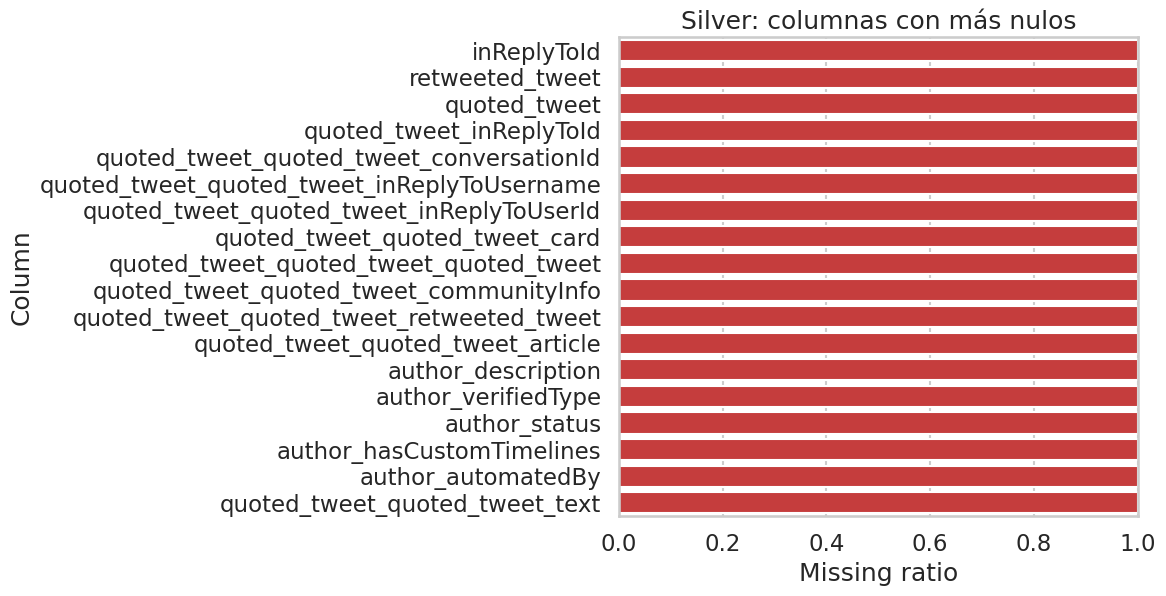

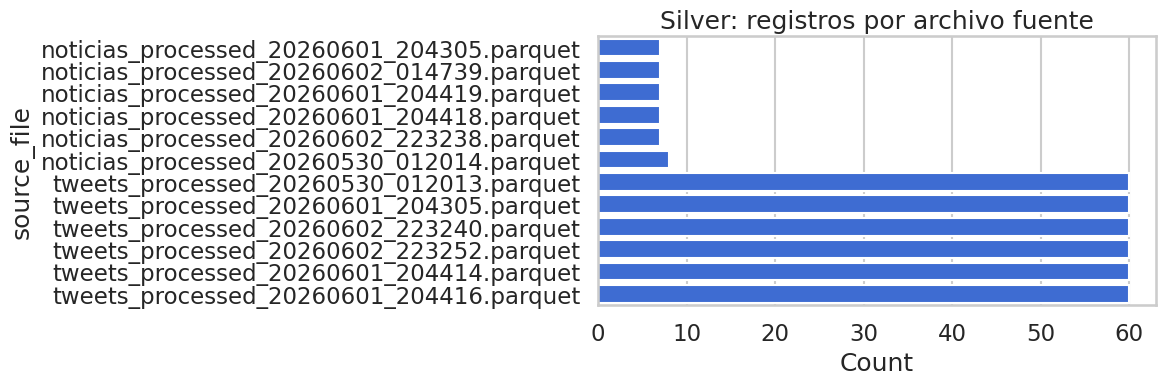

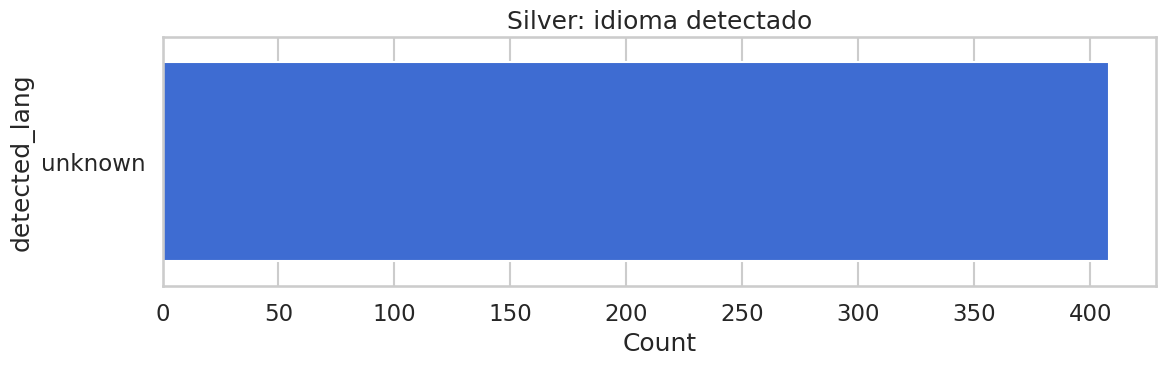

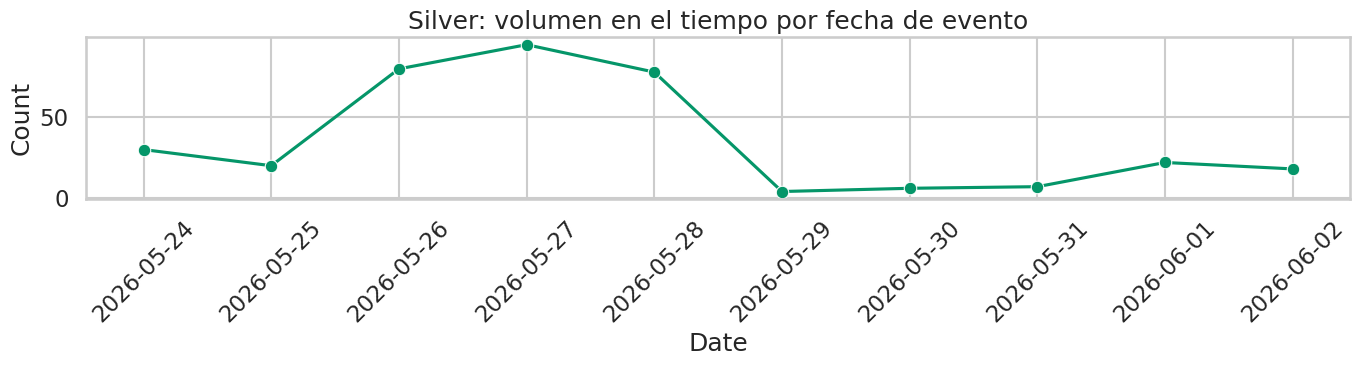

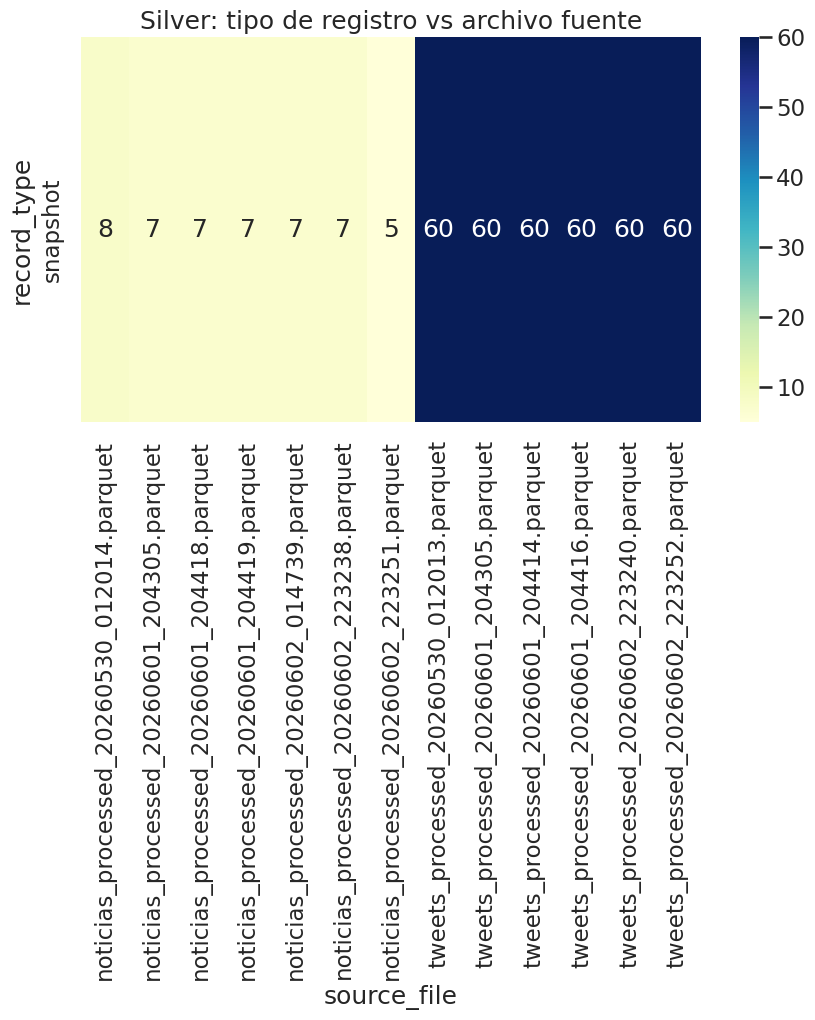

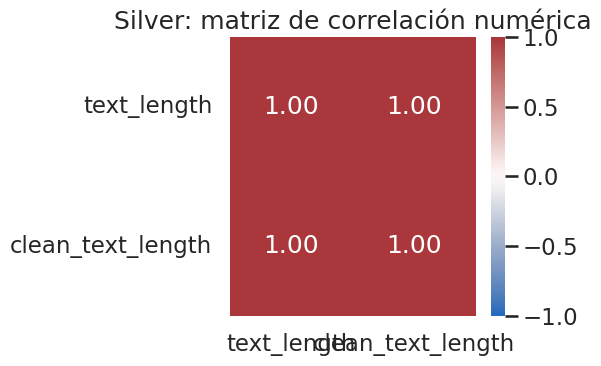

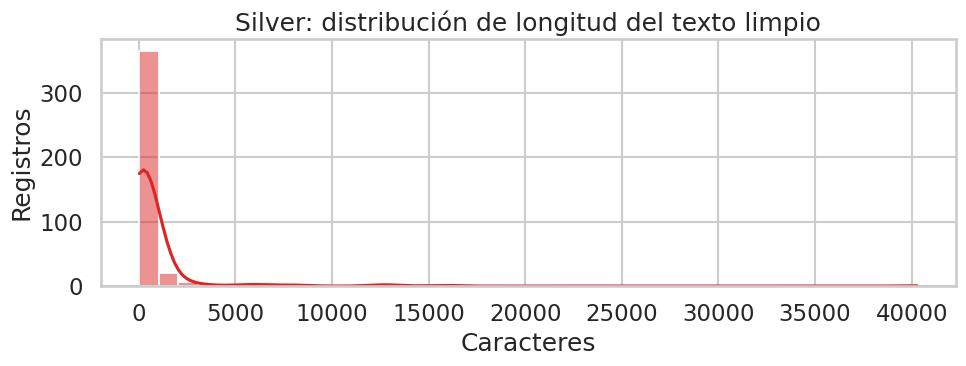

,rows
has_text,
True,408


,record_type,rows,text_ratio
0,snapshot,408,1.0


,metric,value
0,rows with text,408.0
1,rows without text,0.0
2,non-empty text ratio,1.0
3,unique record_type values,1.0


**Lectura ejecutiva:** Silver es el puente entre la extracción y Gold, pero no opera con un solo grano. **Dato clave:** `record_type` separa la lógica de tweet, noticia y comentario; por eso define la estrategia analítica. **Decisión:** los campos con valor real para Gold son texto, autor, tiempo, idioma y engagement; los bloques profundos de quote y perfil quedan fuera de la primera versión.

In [23]:
import seaborn as sns

silver_df = silver_df.copy()
if 'createdAt' in silver_df.columns:
    silver_df['createdAt'] = pd.to_datetime(silver_df['createdAt'], errors='coerce', format='mixed')
if 'updatedAt' in silver_df.columns:
    silver_df['updatedAt'] = pd.to_datetime(silver_df['updatedAt'], errors='coerce', format='mixed')
if 'parsed_datetime' in silver_df.columns:
    silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce', format='mixed')
if 'event_date' in silver_df.columns:
    silver_df['event_date'] = pd.to_datetime(silver_df['event_date'], errors='coerce', format='mixed')

silver_numeric_candidates = [
    'tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount',
    'tweet_viewCount', 'tweet_author_followers', 'tweet_author_following',
    'tweet_author_mediaCount', 'tweet_author_favouritesCount', 'text_length', 'clean_text_length'
]
silver_numeric_cols = [column for column in silver_numeric_candidates if column in silver_df.columns]

display(Markdown('### Silver: patrones, cobertura y candidatos\n\nQué se puede confiar, qué es escaso y qué estructuras sí merecen llegar a Gold.'))

def plot_missingness(df: pd.DataFrame, top_n: int = 18, title: str = 'Missingness') -> None:
    import matplotlib.pyplot as plt

    try:
        import seaborn as sns  # ensure sns available inside the function
    except Exception:
        sns = None

    missing = df.isna().mean().sort_values(ascending=False).head(top_n).sort_values()

    plt.figure(figsize=(12, max(4, 0.35 * len(missing))))
    if sns is not None:
        sns.barplot(x=missing.values, y=missing.index, color='#dc2626')
    else:
        plt.barh(missing.index, missing.values, color='#dc2626')
    plt.title(title)
    plt.xlabel('Missing ratio')
    plt.ylabel('Column')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

plot_missingness(silver_df, top_n=18, title='Silver: columnas con más nulos')
def plot_top_categories(df: pd.DataFrame, column: str, top_n: int = 10, title: str = 'Top Categories') -> None:
    import matplotlib.pyplot as plt
    
    top_values = df[column].value_counts().head(top_n).sort_values()
    
    plt.figure(figsize=(12, max(4, 0.35 * len(top_values))))
    sns.barplot(x=top_values.values, y=top_values.index, color='#2563eb')
    plt.title(title)
    plt.xlabel('Count')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

plot_top_categories(silver_df, 'source_file', top_n=12, title='Silver: registros por archivo fuente')
plot_top_categories(silver_df, 'detected_lang', top_n=12, title='Silver: idioma detectado')

if 'event_date' in silver_df.columns:
    def plot_time_series(df: pd.DataFrame, date_column: str, title: str = 'Time Series') -> None:
        import matplotlib.pyplot as plt
        
        ts_data = df[date_column].dt.date.value_counts().sort_index()
        
        plt.figure(figsize=(14, 4))
        sns.lineplot(x=ts_data.index, y=ts_data.values, marker='o', color='#059669')
        plt.title(title)
        plt.xlabel('Date')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    plot_time_series(silver_df, 'event_date', title='Silver: volumen en el tiempo por fecha de evento')

if 'record_type' in silver_df.columns and 'source_file' in silver_df.columns:
    record_source_matrix = pd.crosstab(silver_df['record_type'], silver_df['source_file'])
    import matplotlib.pyplot as plt
    plt.figure(figsize=(max(10, 0.6 * record_source_matrix.shape[1]), 5))
    if sns is not None:
        sns.heatmap(record_source_matrix, annot=True, fmt='d', cmap='YlGnBu')
    else:
        plt.imshow(record_source_matrix.values, cmap='YlGnBu')
        plt.xticks(range(len(record_source_matrix.columns)), record_source_matrix.columns, rotation=90)
        plt.yticks(range(len(record_source_matrix.index)), record_source_matrix.index)
    plt.title('Silver: tipo de registro vs archivo fuente')
    plt.xlabel('source_file')
    plt.ylabel('record_type')
    plt.tight_layout()
    plt.show()

if silver_numeric_cols:
    def plot_numeric_corr(df: pd.DataFrame, cols: list, title: str = 'Numeric correlation') -> None:
        import matplotlib.pyplot as plt

        if not cols:
            print("No numeric columns provided")
            return

        num_df = df[cols].apply(pd.to_numeric, errors='coerce')
        corr = num_df.corr()

        if corr.empty:
            print("No numeric data to compute correlation")
            return

        plt.figure(figsize=(max(6, 0.6 * len(corr.columns)), max(4, 0.6 * len(corr.index))))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    plot_numeric_corr(silver_df, silver_numeric_cols, title='Silver: matriz de correlación numérica')

if 'clean_text' in silver_df.columns:
    silver_df['clean_text_length'] = silver_df['clean_text'].astype('string').str.len()
    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.histplot(silver_df['clean_text_length'].dropna(), bins=40, kde=True, color='#dc2626')
    else:
        plt.hist(silver_df['clean_text_length'].dropna(), bins=40, color='#dc2626')
    plt.title('Silver: distribución de longitud del texto limpio')
    plt.xlabel('Caracteres')
    plt.ylabel('Registros')
    plt.tight_layout()
    plt.show()

if 'has_text' in silver_df.columns:
    display(silver_df['has_text'].value_counts(dropna=False).to_frame('rows'))

if 'record_type' in silver_df.columns:
    display(silver_df.groupby('record_type').agg(rows=('record_type', 'size'), text_ratio=('has_text', 'mean') if 'has_text' in silver_df.columns else ('record_type', 'size')).reset_index())

def safe_ratio(numerator, denominator):
    """Calculate safe ratio avoiding division by zero."""
    return numerator / denominator if denominator > 0 else 0.0

silver_cleanliness = pd.DataFrame({
    'metric': ['rows with text', 'rows without text', 'non-empty text ratio', 'unique record_type values'],
    'value': [
        int(silver_df['has_text'].sum()) if 'has_text' in silver_df.columns else 0,
        int((~silver_df['has_text']).sum()) if 'has_text' in silver_df.columns else 0,
        safe_ratio(int(silver_df['has_text'].sum()), len(silver_df)) if 'has_text' in silver_df.columns else 0.0,
        int(silver_df['record_type'].nunique(dropna=True)) if 'record_type' in silver_df.columns else 0,
    ]
})
display(silver_cleanliness)

display(Markdown(
    f"**Lectura ejecutiva:** Silver es el puente entre la extracción y Gold, pero no opera con un solo grano. "
    f"**Dato clave:** `record_type` separa la lógica de tweet, noticia y comentario; por eso define la estrategia analítica. "
    f"**Decisión:** los campos con valor real para Gold son texto, autor, tiempo, idioma y engagement; los bloques profundos de quote y perfil quedan fuera de la primera versión."
))

In [24]:
silver_df = silver_df.copy()
silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce', format='mixed') if 'parsed_datetime' in silver_df.columns else pd.NaT
silver_df['event_date'] = pd.to_datetime(silver_df['event_date'], errors='coerce', format='mixed') if 'event_date' in silver_df.columns else pd.NaT


def classify_silver_column(column: str, missing_ratio: float) -> dict:
    lower = column.lower()
    family = 'other'
    represents = 'General technical field'
    business_use = 'Review'
    recommendation = 'Review'
    cleaning_action = 'Inspect before use'
    why_it_matters = 'May contain useful context but needs validation.'

    if column in {'_id'}:
        family = 'lineage'
        represents = 'Internal row identifier'
        business_use = 'Traceability'
        recommendation = 'Keep as lineage'
        cleaning_action = 'No cleaning needed'
        why_it_matters = 'Stable source row id.'
    elif column in {'source_file', 'source_group'}:
        family = 'lineage'
        represents = 'File or source batch name'
        business_use = 'Traceability and batch analysis'
        recommendation = 'Keep as lineage'
        cleaning_action = 'Standardize file naming only if needed'
        why_it_matters = 'Explains which batch produced the row.'
    elif column == 'record_type':
        family = 'grain'
        represents = 'Type of row: tweet, news, or news_comment'
        business_use = 'Primary dataset grain'
        recommendation = 'Keep'
        cleaning_action = 'Normalize categories'
        why_it_matters = 'Separates the three analytical layers.'
    elif column in {'createdAt', 'updatedAt', 'parsed_datetime', 'event_date', 'date'}:
        family = 'time'
        represents = 'Timestamp or event date'
        business_use = 'Trend analysis and refresh tracking'
        recommendation = 'Keep'
        cleaning_action = 'Parse consistently and keep one canonical event date'
        why_it_matters = 'Lets us trend perception over time.'
    elif column in {'raw_text', 'clean_text', 'text_length', 'detected_lang', 'has_text', 'tweet_text', 'comment_text', 'news_comments', 'news_newsLink'}:
        family = 'text_nlp'
        if column == 'news_newsLink':
            represents = 'Article URL linked to the news record'
            business_use = 'Context and article grouping'
            recommendation = 'Keep'
            cleaning_action = 'Validate URL format'
            why_it_matters = 'Useful to group comments by article.'
        else:
            represents = 'Text content or NLP-derived feature'
            business_use = 'Sentiment, topics and QA'
            recommendation = 'Keep'
            cleaning_action = 'Normalize whitespace and preserve raw vs clean text'
            why_it_matters = 'Core input for NLP or QA.'
    elif lower.startswith('tweet_author_'):
        family = 'author'
        represents = 'Tweet author profile attribute'
        business_use = 'Influence, segmentation and credibility'
        recommendation = 'Keep' if not any(k in lower for k in ['profile_bio_entities', 'pinnedtweetids', 'coverpicture', 'profilepicture']) else 'Review'
        cleaning_action = 'Keep core fields, review rich profile blobs'
        why_it_matters = 'Important for influencer and author analysis.'
    elif lower.startswith('tweet_quoted_tweet_quoted_tweet_'):
        family = 'deep_quote'
        represents = 'Quoted tweet nested inside another quoted tweet'
        business_use = 'Rare edge-case context'
        recommendation = 'Drop for Gold'
        cleaning_action = 'Drop unless quote-chain analysis is required'
        why_it_matters = 'Extremely sparse and expensive to maintain.'
    elif lower.startswith('tweet_quoted_tweet_'):
        family = 'quote'
        represents = 'Quoted tweet metadata and content'
        business_use = 'Conversation context and amplification'
        recommendation = 'Review'
        cleaning_action = 'Keep only the fields relevant to quote analysis'
        why_it_matters = 'Useful when quote-tweet behavior matters.'
    elif lower.startswith('tweet_'):
        family = 'tweet'
        represents = 'Tweet-level field'
        business_use = 'Core tweet analysis'
        recommendation = 'Keep' if any(k in lower for k in ['id', 'createdat', 'lang', 'source', 'likecount', 'replycount', 'retweetcount', 'quotecount', 'viewcount', 'isreply', 'conversationid']) else 'Review'
        cleaning_action = 'Cast numeric / boolean types and remove nested blobs if not needed'
        why_it_matters = 'Core tweet signal for Gold.'
    elif lower.startswith('news_'):
        family = 'news'
        represents = 'Web scraping news/article attribute'
        business_use = 'Article context and comment analysis'
        recommendation = 'Keep' if any(k in lower for k in ['id', 'newslink', 'comments', 'createdat']) else 'Review'
        cleaning_action = 'Keep context fields, flatten arrays only when needed'
        why_it_matters = 'Defines the article side of Silver.'

    if missing_ratio > 0.9 and recommendation == 'Keep':
        recommendation = 'Review'
        why_it_matters = 'Coverage is very low, so keep only if the use case is strong.'
    if missing_ratio > 0.95 and recommendation == 'Review' and family in {'quote', 'deep_quote', 'news', 'author'}:
        recommendation = 'Drop for Gold'
        cleaning_action = 'Exclude from first Gold version'
        why_it_matters = 'Very sparse and unlikely to improve the first Gold layer.'

    return {
        'column': column,
        'family': family,
        'represents': represents,
        'business_use': business_use,
        'recommendation': recommendation,
        'cleaning_action': cleaning_action,
        'why_it_matters': why_it_matters,
        'missing_ratio': missing_ratio,
    }


silver_audit = audit_frame(silver_df)
silver_catalog = pd.DataFrame([
    classify_silver_column(row['column'], float(row['missing_ratio']))
    for _, row in silver_audit.iterrows()
]).sort_values(['recommendation', 'missing_ratio', 'column'], ascending=[True, False, True])

silver_quality = pd.DataFrame(
    [
        {'metric': 'rows', 'value': len(silver_df)},
        {'metric': 'rows with id', 'value': int(silver_df['_id'].notna().sum()) if '_id' in silver_df.columns else 0},
        {'metric': 'unique ids', 'value': int(silver_df['_id'].nunique(dropna=True)) if '_id' in silver_df.columns else 0},
        {'metric': 'rows with text', 'value': int(silver_df['clean_text'].notna().sum()) if 'clean_text' in silver_df.columns else 0},
        {
            'metric': 'non-empty text ratio',
            'value': float(silver_df['clean_text'].notna().mean()) if 'clean_text' in silver_df.columns and len(silver_df) else 0.0,
        },
        {
            'metric': 'rows with parsed_datetime',
            'value': int(silver_df['parsed_datetime'].notna().sum()) if 'parsed_datetime' in silver_df.columns else 0,
        },
        {
            'metric': 'rows with event_date',
            'value': int(silver_df['event_date'].notna().sum()) if 'event_date' in silver_df.columns else 0,
        },
    ]
)
silver_quality['value'] = silver_quality['value'].apply(
    lambda x: round(float(x), 4) if isinstance(x, (int, float)) and pd.notna(x) else x
)

silver_family_summary = silver_catalog.groupby(['family', 'recommendation']).size().reset_index(name='columns')

print('Silver quality summary')
display(silver_quality)
print('Silver family summary')
display(silver_family_summary.sort_values(['family', 'recommendation']))
print('Silver column catalog')
display(silver_catalog.head(120))
print('Silver top missing columns')
display(silver_audit.head(20))

Silver quality summary


,metric,value
0,rows,408.0
1,rows with id,48.0
2,unique ids,27.0
3,rows with text,408.0
4,non-empty text ratio,1.0
5,rows with parsed_datetime,360.0
6,rows with event_date,360.0


Silver family summary


,family,recommendation,columns
0,grain,Keep,1
1,lineage,Keep as lineage,3
2,other,Review,151
3,text_nlp,Keep,5
4,time,Keep,3


Silver column catalog


,column,family,represents,business_use,recommendation,cleaning_action,why_it_matters,missing_ratio
140,createdAt,time,Timestamp or event date,Trend analysis and refresh tracking,Keep,Parse consistently and keep one canonical event date,Lets us trend perception over time.,0.117647
141,event_date,time,Timestamp or event date,Trend analysis and refresh tracking,Keep,Parse consistently and keep one canonical event date,Lets us trend perception over time.,0.117647
147,parsed_datetime,time,Timestamp or event date,Trend analysis and refresh tracking,Keep,Parse consistently and keep one canonical event date,Lets us trend perception over time.,0.117647
154,clean_text,text_nlp,Text content or NLP-derived feature,"Sentiment, topics and QA",Keep,Normalize whitespace and preserve raw vs clean text,Core input for NLP or QA.,0.000000
156,detected_lang,text_nlp,Text content or NLP-derived feature,"Sentiment, topics and QA",Keep,Normalize whitespace and preserve raw vs clean text,Core input for NLP or QA.,0.000000
...,...,...,...,...,...,...,...,...
104,quoted_tweet_retweetCount,other,General technical field,Review,Review,Inspect before use,May contain useful context but needs validation.,0.845588
105,quoted_tweet_source,other,General technical field,Review,Review,Inspect before use,May contain useful context but needs validation.,0.845588
106,quoted_tweet_text,other,General technical field,Review,Review,Inspect before use,May contain useful context but needs validation.,0.845588
107,quoted_tweet_twitterUrl,other,General technical field,Review,Review,Inspect before use,May contain useful context but needs validation.,0.845588


Silver top missing columns


,column,dtype,missing_ratio,non_null_count,nunique
147,author_automatedBy,float64,1.0,0,0
127,author_description,float64,1.0,0,0
138,author_hasCustomTimelines,float64,1.0,0,0
131,author_status,float64,1.0,0,0
124,author_verifiedType,float64,1.0,0,0
13,inReplyToId,float64,1.0,0,0
16,quoted_tweet,float64,1.0,0,0
77,quoted_tweet_article,float64,1.0,0,0
70,quoted_tweet_author_automatedBy,float64,1.0,0,0
50,quoted_tweet_author_description,float64,1.0,0,0


## Bronze: Column Dictionary and Business Interpretation

Aquí explicamos columna por columna qué representa, por qué existe, si aporta valor a Gold y qué limpieza requiere antes de modelar.

## Bronze: Patterns, Quality and Model-Ready Signals

Ahora miramos qué nos dice el Bronze en términos de volumen, idioma, autores, engagement y consistencia de campos. Esto nos ayuda a decidir qué columnas sí alimentan Gold y cuáles son solo metadatos operativos.

Info: 'tweet_day' set to NA — no datetime column available


## Bronze: patrones y señales de calidad

Qué señales aportan valor y cuáles son lineage o ruido.

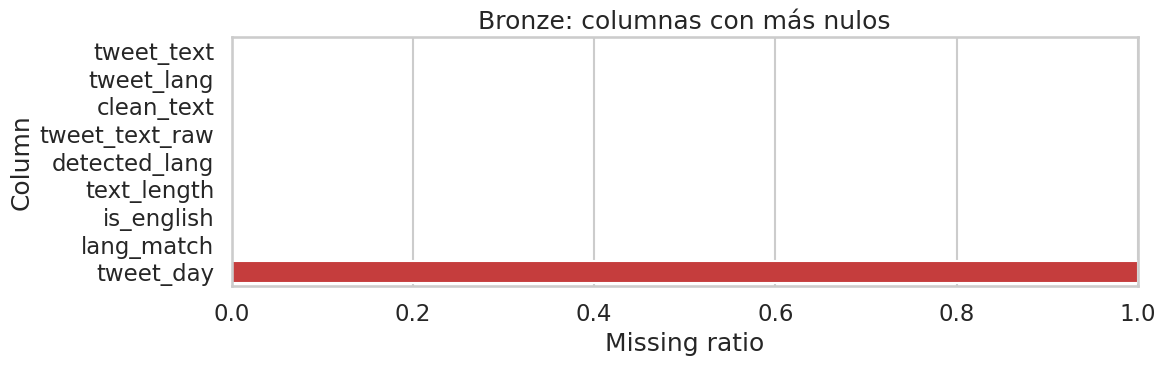

Info: no datetime column available for time series plot
Info: no author column available for top authors plot


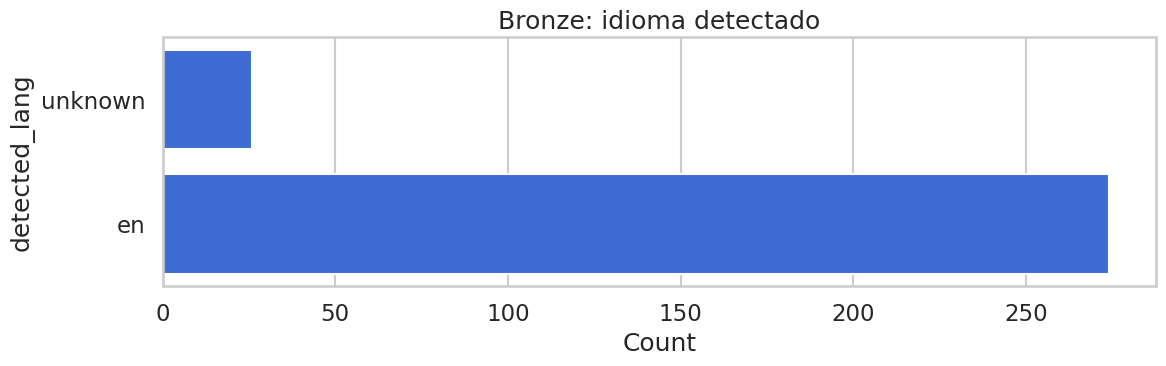

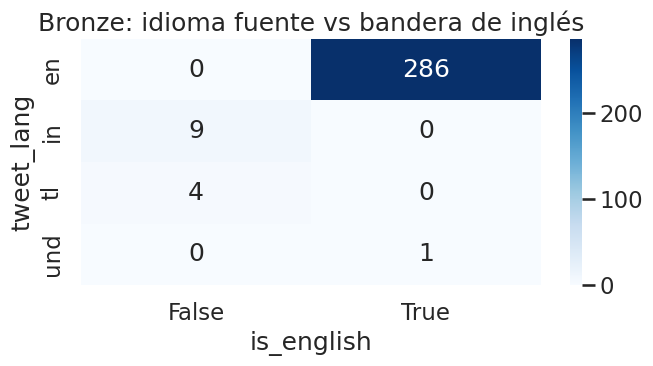

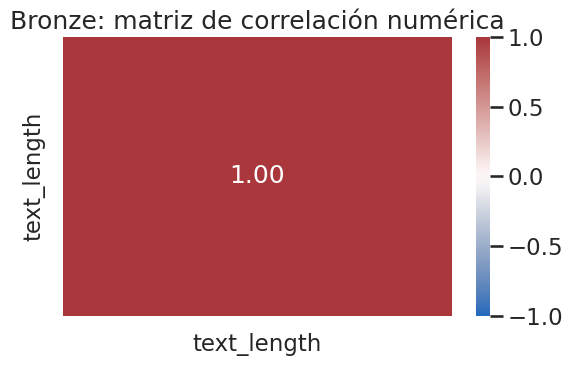

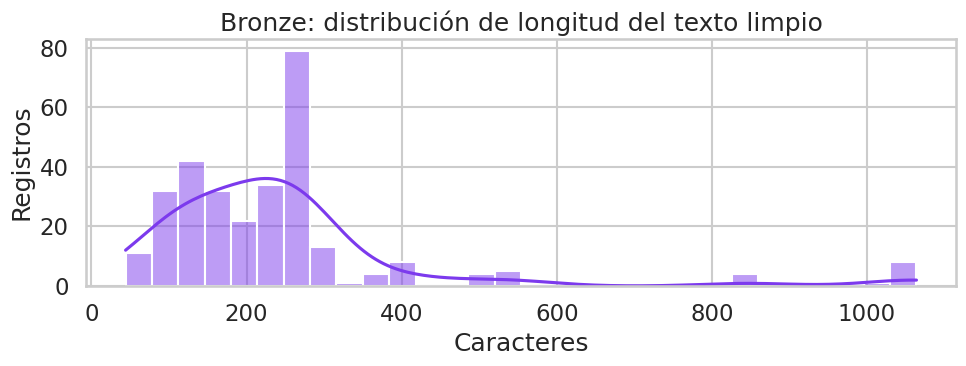

,metric,missing_ratio,mean,median,p95
0,text_length,0.0,247.65,222.0,551.0


**Lectura ejecutiva:** Bronze es claramente tweet-céntrico y presenta una cobertura alta de texto. **Dato clave:** `tweet_text_raw` y `clean_text` son prácticamente equivalentes, por lo que Gold solo necesita una versión canónica del texto más el texto limpio. **Decisión:** la metadata operacional se excluye de Gold y se conservan idioma, autor, fecha y métricas de interacción como señales principales.

In [25]:
bronze_df = bronze_df.copy()
if 'tweet_createdAt' in bronze_df.columns:
    bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
else:
    # If tweet_createdAt doesn't exist, create a placeholder or skip this step
    print("Warning: 'tweet_createdAt' column not found in bronze_df")
bronze_df = bronze_df.copy()
if 'tweet_createdAt' in bronze_df.columns:
    bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
else:
    print("Warning: 'tweet_createdAt' column not found in bronze_df")

# Safely derive tweet_day from the best available datetime column
if 'tweet_createdAt' in bronze_df.columns:
    bronze_df['tweet_day'] = bronze_df['tweet_createdAt'].dt.date.astype('string')
elif 'parsed_datetime' in bronze_df.columns:
    bronze_df['tweet_day'] = pd.to_datetime(bronze_df['parsed_datetime'], errors='coerce', format='mixed').dt.date.astype('string')
elif 'event_date' in bronze_df.columns:
    bronze_df['tweet_day'] = pd.to_datetime(bronze_df['event_date'], errors='coerce', format='mixed').dt.date.astype('string')
else:
    bronze_df['tweet_day'] = pd.NA
    print("Info: 'tweet_day' set to NA — no datetime column available")

bronze_numeric_cols = [
    'tweet_retweetCount', 'tweet_replyCount', 'tweet_likeCount', 'tweet_quoteCount',
    'tweet_viewCount', 'tweet_author_followers', 'tweet_author_following', 'text_length'
]
bronze_numeric_cols = [column for column in bronze_numeric_cols if column in bronze_df.columns]

display(Markdown(
    "## Bronze: patrones y señales de calidad\n\n"
    "Qué señales aportan valor y cuáles son lineage o ruido."
))

plot_missingness(bronze_df, top_n=12, title='Bronze: columnas con más nulos')
time_column = next(
    (column for column in ['tweet_createdAt', 'parsed_datetime', 'event_date'] if column in bronze_df.columns),
    None
)

if time_column is not None:
    plot_time_series(bronze_df, time_column, title='Bronze: volumen de tweets en el tiempo')
else:
    print("Info: no datetime column available for time series plot")
author_column = next(
    (column for column in ['tweet_author_userName', 'author_userName', 'author_name'] if column in bronze_df.columns),
    None
)

if author_column is not None:
    plot_top_categories(bronze_df, author_column, top_n=10, title=f'Bronze: autores más activos ({author_column})')
else:
    print("Info: no author column available for top authors plot")
plot_top_categories(bronze_df, 'detected_lang', top_n=10, title='Bronze: idioma detectado')

if 'tweet_lang' in bronze_df.columns and 'is_english' in bronze_df.columns:
    bronze_lang_matrix = pd.crosstab(bronze_df['tweet_lang'].fillna('Unknown'), bronze_df['is_english'])
    plt.figure(figsize=(7, 4))
    if sns is not None:
        sns.heatmap(bronze_lang_matrix, annot=True, fmt='d', cmap='Blues')
    else:
        plt.imshow(bronze_lang_matrix.values, cmap='Blues')
        plt.xticks(range(len(bronze_lang_matrix.columns)), bronze_lang_matrix.columns)
        plt.yticks(range(len(bronze_lang_matrix.index)), bronze_lang_matrix.index)
    plt.title('Bronze: idioma fuente vs bandera de inglés')
    plt.xlabel('is_english')
    plt.ylabel('tweet_lang')
    plt.tight_layout()
    plt.show()

if bronze_numeric_cols:
    plot_numeric_corr(bronze_df, bronze_numeric_cols, title='Bronze: matriz de correlación numérica')

if 'clean_text' in bronze_df.columns:
    bronze_df['clean_text_length'] = bronze_df['clean_text'].astype('string').str.len()
    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.histplot(bronze_df['clean_text_length'].dropna(), bins=30, kde=True, color='#7c3aed')
    else:
        plt.hist(bronze_df['clean_text_length'].dropna(), bins=30, color='#7c3aed')
    plt.title('Bronze: distribución de longitud del texto limpio')
    plt.xlabel('Caracteres')
    plt.ylabel('Registros')
    plt.tight_layout()
    plt.show()

engagement_summary = pd.DataFrame({
    'metric': bronze_numeric_cols,
    'missing_ratio': [float(bronze_df[column].isna().mean()) for column in bronze_numeric_cols],
    'mean': [float(pd.to_numeric(bronze_df[column], errors='coerce').mean()) for column in bronze_numeric_cols],
    'median': [float(pd.to_numeric(bronze_df[column], errors='coerce').median()) for column in bronze_numeric_cols],
    'p95': [float(pd.to_numeric(bronze_df[column], errors='coerce').quantile(0.95)) for column in bronze_numeric_cols],
})
display(engagement_summary.sort_values('mean', ascending=False))

display(Markdown(
    f"**Lectura ejecutiva:** Bronze es claramente tweet-céntrico y presenta una cobertura alta de texto. "
    f"**Dato clave:** `tweet_text_raw` y `clean_text` son prácticamente equivalentes, por lo que Gold solo necesita una versión canónica del texto más el texto limpio. "
    f"**Decisión:** la metadata operacional se excluye de Gold y se conservan idioma, autor, fecha y métricas de interacción como señales principales."
))

In [26]:
bronze_df = globals().get('bronze_df', load_csv(BRONZE_EDA_CSV))
silver_df = globals().get('silver_df', load_csv(SILVER_EDA_CSV))
bronze_df = globals().get('bronze_df', load_csv(BRONZE_EDA_CSV))
silver_df = globals().get('silver_df', load_csv(SILVER_EDA_CSV))

# Safely call add_datetime_features if defined; otherwise apply equivalent logic inline.
_adder = globals().get('add_datetime_features')
if callable(_adder):
    bronze_df = _adder(bronze_df, 'tweet_createdAt', 'tweet_event_date')
else:
    if 'tweet_createdAt' in bronze_df.columns:
        bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
        bronze_df['tweet_event_date'] = bronze_df['tweet_createdAt'].dt.date.astype('string')
    else:
        bronze_df['tweet_event_date'] = pd.NA

bronze_catalog = pd.DataFrame([
    {'column': 'snapshot_bronze_file', 'represents': 'Bronze file name that produced the row', 'business_use': 'Lineage and traceability', 'recommendation': 'Keep as lineage', 'cleaning_action': 'No cleaning needed', 'why_it_matters': 'Lets us explain where each row came from.'},
    {'column': 'snapshot__id', 'represents': 'Internal snapshot identifier from the Bronze extraction', 'business_use': 'Technical traceability', 'recommendation': 'Keep as lineage', 'cleaning_action': 'No cleaning needed', 'why_it_matters': 'Useful for audits, not usually for modeling.'},
    {'column': 'snapshot_has_next_page', 'represents': 'Whether the original ingestion still had more pages', 'business_use': 'Extraction QA', 'recommendation': 'Drop from Gold', 'cleaning_action': 'Keep only in raw/bronze', 'why_it_matters': 'Operational metadata, not analytical signal.'},
    {'column': 'snapshot_next_cursor', 'represents': 'Pagination cursor used to continue extraction', 'business_use': 'Extraction QA', 'recommendation': 'Drop from Gold', 'cleaning_action': 'Drop after ingestion', 'why_it_matters': 'Pure process metadata.'},
    {'column': 'tweet_id', 'represents': 'Unique tweet identifier', 'business_use': 'Primary business key for tweet-level analysis', 'recommendation': 'Keep', 'cleaning_action': 'Validate uniqueness and nulls', 'why_it_matters': 'Main join key for tweet-level Gold.'},
    {'column': 'tweet_text', 'represents': 'Original tweet body as extracted', 'business_use': 'NLP source text', 'recommendation': 'Keep only one raw text field', 'cleaning_action': 'Compare with tweet_text_raw and avoid duplication', 'why_it_matters': 'Source text for sentiment and topic analysis.'},
    {'column': 'tweet_createdAt', 'represents': 'Tweet publication timestamp', 'business_use': 'Trend, seasonality, time series', 'recommendation': 'Keep', 'cleaning_action': 'Parse as datetime and standardize timezone', 'why_it_matters': 'Needed for daily/weekly brand perception trends.'},
    {'column': 'tweet_lang', 'represents': 'Language reported by the source', 'business_use': 'Language filtering and QA', 'recommendation': 'Keep', 'cleaning_action': 'Normalize codes and compare with detected_lang', 'why_it_matters': 'Helps verify whether text is analyzable.'},
    {'column': 'tweet_source', 'represents': 'Platform/app used to publish the tweet', 'business_use': 'Channel segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Normalize categories if needed', 'why_it_matters': 'Shows how people publish and from which client.'},
    {'column': 'tweet_retweetCount', 'represents': 'Number of retweets', 'business_use': 'Reach / amplification', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, inspect outliers', 'why_it_matters': 'Measures virality and diffusion.'},
    {'column': 'tweet_replyCount', 'represents': 'Number of replies', 'business_use': 'Conversation depth', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, inspect zeros and spikes', 'why_it_matters': 'Shows conversation intensity.'},
    {'column': 'tweet_likeCount', 'represents': 'Number of likes', 'business_use': 'Engagement / approval', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, use log scale for visuals', 'why_it_matters': 'Approximate signal of positive reception.'},
    {'column': 'tweet_quoteCount', 'represents': 'Number of quote tweets', 'business_use': 'Amplification with commentary', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric', 'why_it_matters': 'Useful to study polarized or influential posts.'},
    {'column': 'tweet_viewCount', 'represents': 'Number of views', 'business_use': 'Exposure', 'recommendation': 'Keep if populated', 'cleaning_action': 'Inspect missingness and magnitude', 'why_it_matters': 'Lets us normalize engagement by exposure.'},
    {'column': 'tweet_isReply', 'represents': 'Whether the tweet is a reply', 'business_use': 'Conversation role', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Separates original posts from reactions.'},
    {'column': 'tweet_conversationId', 'represents': 'Thread/conversation identifier', 'business_use': 'Thread analysis', 'recommendation': 'Keep', 'cleaning_action': 'Validate format', 'why_it_matters': 'Allows grouping replies inside conversations.'},
    {'column': 'tweet_author_userName', 'represents': 'Author handle', 'business_use': 'Author segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Normalize case and trim spaces', 'why_it_matters': 'Needed to identify users and compare activity.'},
    {'column': 'tweet_author_name', 'represents': 'Display name of the author', 'business_use': 'Human-readable identity', 'recommendation': 'Keep', 'cleaning_action': 'Fill missing with handle when needed', 'why_it_matters': 'Improves readability of outputs and dashboards.'},
    {'column': 'tweet_author_id', 'represents': 'Author unique id', 'business_use': 'Author deduplication', 'recommendation': 'Keep', 'cleaning_action': 'Check duplicates and nulls', 'why_it_matters': 'Stable identifier for author-level analysis.'},
    {'column': 'tweet_author_followers', 'represents': 'Followers of the author', 'business_use': 'Influence / reach proxy', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric and cap outliers if needed', 'why_it_matters': 'Helps identify influential accounts.'},
    {'column': 'tweet_author_following', 'represents': 'Accounts followed by the author', 'business_use': 'Account profile depth', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric', 'why_it_matters': 'Useful for spam/behavior patterns.'},
    {'column': 'tweet_author_isVerified', 'represents': 'Verified status flag', 'business_use': 'Credibility segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Separate verified from non-verified voices.'},
    {'column': 'tweet_author_isBlueVerified', 'represents': 'Blue verification flag', 'business_use': 'Credibility segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Captures current X/Twitter verification behavior.'},
    {'column': 'tweet_author_location', 'represents': 'Declared location of the author', 'business_use': 'Geographic context', 'recommendation': 'Review', 'cleaning_action': 'Standardize only if location analysis is needed', 'why_it_matters': 'Often sparse or noisy, but useful for regional studies.'},
    {'column': 'tweet_author_createdAt', 'represents': 'Account creation date', 'business_use': 'Account age / maturity', 'recommendation': 'Keep', 'cleaning_action': 'Parse as datetime', 'why_it_matters': 'Can highlight new vs mature accounts.'},
    {'column': 'tweet_text_raw', 'represents': 'Raw text preserved for NLP and QA', 'business_use': 'Source text for cleaning', 'recommendation': 'Keep', 'cleaning_action': 'Deduplicate against tweet_text if identical', 'why_it_matters': 'Auditability and reproducible NLP.'},
    {'column': 'clean_text', 'represents': 'Cleaned text ready for NLP', 'business_use': 'Sentiment and topic modeling', 'recommendation': 'Keep', 'cleaning_action': 'Remove URLs, mentions, duplicated whitespace', 'why_it_matters': 'Core input for NLP.'},
    {'column': 'text_length', 'represents': 'Length of cleaned text', 'business_use': 'Quality and feature engineering', 'recommendation': 'Keep', 'cleaning_action': 'Inspect outliers', 'why_it_matters': 'Useful as a proxy for verbosity and spam.'},
    {'column': 'detected_lang', 'represents': 'Language inferred from clean text', 'business_use': 'Language QA and filtering', 'recommendation': 'Keep', 'cleaning_action': 'Compare with tweet_lang', 'why_it_matters': 'Confirms whether the text is analyzable.'},
    {'column': 'is_english', 'represents': 'Boolean flag for English analysis', 'business_use': 'Subset selection for NLP', 'recommendation': 'Keep as QA flag', 'cleaning_action': 'Use only if the model is English-only', 'why_it_matters': 'Supports controlled language filtering.'},
    {'column': 'lang_match', 'represents': 'Whether source language and detected language match', 'business_use': 'Data quality check', 'recommendation': 'Keep as QA flag', 'cleaning_action': 'Interpret as quality indicator', 'why_it_matters': 'Flags uncertain or noisy rows.'},
])

_qs = globals().get('quality_summary')
if callable(_qs):
    bronze_quality = _qs(bronze_df, id_col='tweet_id', text_col='clean_text', date_col='tweet_createdAt')
else:
    summary = {
        'rows': len(bronze_df),
        'columns': len(bronze_df.columns),
        'duplicate_rows': int(bronze_df.duplicated().sum()),
        'duplicate_rate': float(bronze_df.duplicated().mean()) if len(bronze_df) else 0.0,
    }
    if 'tweet_id' in bronze_df.columns:
        summary['id_null_rate'] = float(bronze_df['tweet_id'].isna().mean())
        summary['id_unique_rate'] = float(bronze_df['tweet_id'].nunique(dropna=True) / len(bronze_df)) if len(bronze_df) else 0.0
    if 'clean_text' in bronze_df.columns:
        text_series = bronze_df['clean_text'].fillna('').astype('string')
        summary['text_missing_rate'] = float((text_series.str.len() == 0).mean())
        summary['avg_text_length'] = float(text_series.str.len().mean())
    if 'tweet_createdAt' in bronze_df.columns:
        summary['date_missing_rate'] = float(pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed').isna().mean())
    bronze_quality = pd.DataFrame([summary]).T.rename(columns={0: 'value'})
bronze_duplicate_check = pd.DataFrame([
    {
        'check': 'tweet_text_vs_tweet_text_raw_equal_ratio',
        'value': safe_ratio((bronze_df['tweet_text'].fillna('') == bronze_df['tweet_text_raw'].fillna('')).sum(), len(bronze_df)),
    },
    {
        'check': 'tweet_text_raw_null_rate',
        'value': float(bronze_df['tweet_text_raw'].isna().mean()),
    },
    {
        'check': 'clean_text_null_or_empty_rate',
        'value': float((bronze_df['clean_text'].fillna('').astype('string').str.len() == 0).mean()),
    },
])

print('Bronze quality summary')
display(bronze_quality)
print('Bronze column dictionary')
display(bronze_catalog)
print('Bronze text duplication checks')
display(bronze_duplicate_check)
print('Bronze top missing columns')
display(audit_frame(bronze_df).head(12))

Bronze quality summary


,value
rows,300.000000
columns,10.000000
duplicate_rows,182.000000
duplicate_rate,0.606667
text_missing_rate,0.000000
avg_text_length,247.650000


Bronze column dictionary


,column,represents,business_use,recommendation,cleaning_action,why_it_matters
0,snapshot_bronze_file,Bronze file name that produced the row,Lineage and traceability,Keep as lineage,No cleaning needed,Lets us explain where each row came from.
1,snapshot__id,Internal snapshot identifier from the Bronze extraction,Technical traceability,Keep as lineage,No cleaning needed,"Useful for audits, not usually for modeling."
2,snapshot_has_next_page,Whether the original ingestion still had more pages,Extraction QA,Drop from Gold,Keep only in raw/bronze,"Operational metadata, not analytical signal."
3,snapshot_next_cursor,Pagination cursor used to continue extraction,Extraction QA,Drop from Gold,Drop after ingestion,Pure process metadata.
4,tweet_id,Unique tweet identifier,Primary business key for tweet-level analysis,Keep,Validate uniqueness and nulls,Main join key for tweet-level Gold.
5,tweet_text,Original tweet body as extracted,NLP source text,Keep only one raw text field,Compare with tweet_text_raw and avoid duplication,Source text for sentiment and topic analysis.
6,tweet_createdAt,Tweet publication timestamp,"Trend, seasonality, time series",Keep,Parse as datetime and standardize timezone,Needed for daily/weekly brand perception trends.
7,tweet_lang,Language reported by the source,Language filtering and QA,Keep,Normalize codes and compare with detected_lang,Helps verify whether text is analyzable.
8,tweet_source,Platform/app used to publish the tweet,Channel segmentation,Keep,Normalize categories if needed,Shows how people publish and from which client.
9,tweet_retweetCount,Number of retweets,Reach / amplification,Keep,"Cast to numeric, inspect outliers",Measures virality and diffusion.


Bronze text duplication checks


,check,value
0,tweet_text_vs_tweet_text_raw_equal_ratio,1.0
1,tweet_text_raw_null_rate,0.0
2,clean_text_null_or_empty_rate,0.0


Bronze top missing columns


,column,dtype,missing_ratio,non_null_count,nunique
8,tweet_day,object,1.0,0,0
3,clean_text,str,0.0,300,118
9,clean_text_length,Int64,0.0,300,98
5,detected_lang,str,0.0,300,2
6,is_english,bool,0.0,300,2
7,lang_match,bool,0.0,300,2
4,text_length,int64,0.0,300,98
1,tweet_lang,str,0.0,300,4
0,tweet_text,str,0.0,300,118
2,tweet_text_raw,str,0.0,300,118


In [27]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
try:
    import seaborn as sns
except ImportError:
    sns = None

from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

if sns is not None:
    sns.set_theme(style='whitegrid', context='talk')

pd.set_option('display.max_columns', 250)
pd.set_option('display.max_colwidth', 120)


def ensure_loaded() -> tuple[pd.DataFrame, pd.DataFrame]:
    global bronze_df, silver_df
    if 'bronze_df' not in globals():
        bronze_df = load_csv(BRONZE_EDA_CSV)
    if 'silver_df' not in globals():
        silver_df = load_csv(SILVER_EDA_CSV)
    return bronze_df, silver_df



def add_datetime_features(df: pd.DataFrame, column: str, target_name: str) -> pd.DataFrame:
    result = df.copy()
    if column in result.columns:
        result[column] = pd.to_datetime(result[column], errors='coerce', format='mixed')
        result[target_name] = result[column].dt.date.astype('string')
    return result



def section(title: str, subtitle: str | None = None) -> None:
    lines = [f'## {title}']
    if subtitle:
        lines.append(subtitle)
    display(Markdown('\n\n'.join(lines)))



def audit_frame(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_ratio': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
        'nunique': [df[col].nunique(dropna=True) for col in df.columns],
    }).sort_values(['missing_ratio', 'column'], ascending=[False, True])



def quality_summary(df: pd.DataFrame, id_col: str | None = None, text_col: str | None = None, date_col: str | None = None) -> pd.DataFrame:
    summary = {
        'rows': len(df),
        'columns': len(df.columns),
        'duplicate_rows': int(df.duplicated().sum()),
        'duplicate_rate': float(df.duplicated().mean()) if len(df) else 0.0,
    }
    if id_col and id_col in df.columns:
        summary['id_null_rate'] = float(df[id_col].isna().mean())
        summary['id_unique_rate'] = float(df[id_col].nunique(dropna=True) / len(df)) if len(df) else 0.0
    if text_col and text_col in df.columns:
        text_series = df[text_col].fillna('').astype('string')
        summary['text_missing_rate'] = float((text_series.str.len() == 0).mean())
        summary['avg_text_length'] = float(text_series.str.len().mean())
    if date_col and date_col in df.columns:
        summary['date_missing_rate'] = float(pd.to_datetime(df[date_col], errors='coerce', format='mixed').isna().mean())
    return pd.DataFrame([summary]).T.rename(columns={0: 'value'})



def top_values(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame()
    return df[column].fillna('Unknown').value_counts(dropna=False).head(n).to_frame('rows')



def plot_missingness(df: pd.DataFrame, top_n: int = 15, title: str = '') -> None:
    audit = audit_frame(df).head(top_n).iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.4 * len(audit) + 2)))
    if sns is not None:
        sns.barplot(data=audit, x='missing_ratio', y='column', color='#2563eb')
    else:
        plt.barh(audit['column'], audit['missing_ratio'], color='#2563eb')
    plt.title(title or 'Columnas con más nulos')
    plt.xlabel('Proporción de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()



def plot_numeric_corr(df: pd.DataFrame, columns: list[str], title: str = '') -> None:
    numeric = [column for column in columns if column in df.columns]
    if len(numeric) < 2:
        print('No hay suficientes columnas numéricas para calcular la correlación.')
        return

    numeric_df = df[numeric].apply(pd.to_numeric, errors='coerce')
    corr = numeric_df.corr(numeric_only=True).round(2)
    if corr.empty:
        print('La matriz de correlación está vacía.')
        return

    label_map = {
        'tweet_retweetCount': 'rt',
        'tweet_replyCount': 'rep',
        'tweet_likeCount': 'like',
        'tweet_quoteCount': 'quote',
        'tweet_viewCount': 'views',
        'tweet_author_followers': 'followers',
        'tweet_author_following': 'following',
        'tweet_author_mediaCount': 'media',
        'tweet_author_favouritesCount': 'favs',
        'text_length': 'txt_len',
        'clean_text_length': 'clean_len',
    }
    corr.columns = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.columns]
    corr.index = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.index]

    mask = np.triu(np.ones_like(corr, dtype=bool))
    size = max(7.0, 0.85 * len(corr.columns) + 3.0)
    annot = len(corr.columns) <= 12

    plt.figure(figsize=(size, size))
    if sns is not None:
        sns.heatmap(
            corr,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.6,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            annot=annot,
            fmt='.2f',
            annot_kws={'size': 8},
        )
    else:
        masked = np.ma.masked_where(mask, corr.values)
        plt.imshow(masked, cmap='RdBu_r', vmin=-1, vmax=1)
        plt.colorbar(label='Correlación', shrink=0.8)
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=35, ha='right')
        plt.yticks(range(len(corr.index)), corr.index)

    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.title(title or 'Matriz de correlación')
    plt.tight_layout()
    plt.show()



def plot_top_categories(df: pd.DataFrame, column: str, top_n: int = 10, title: str = '') -> None:
    if column not in df.columns:
        print(f'{column} no existe en el dataframe.')
        return
    values = df[column].fillna('Unknown').value_counts(dropna=False).head(top_n).sort_values()
    plt.figure(figsize=(11, max(5, 0.4 * len(values) + 2)))
    if sns is not None:
        sns.barplot(x=values.values, y=values.index, color='#0f766e')
    else:
        plt.barh(values.index, values.values, color='#0f766e')
    plt.title(title or f'Top {top_n} valores para {column}')
    plt.xlabel('Registros')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()



def plot_time_series(df: pd.DataFrame, date_col: str, title: str = '') -> None:
    if date_col not in df.columns:
        print(f'{date_col} no existe en el dataframe.')
        return
    series = pd.to_datetime(df[date_col], errors='coerce', format='mixed').dt.date.value_counts().sort_index()
    if series.empty:
        print(f'No hay fechas válidas en {date_col}.')
        return
    plt.figure(figsize=(12, 5))
    plt.plot(series.index, series.values, marker='o', color='#7c3aed')
    plt.title(title or f'Volumen en el tiempo por {date_col}')
    plt.xlabel('Fecha')
    plt.ylabel('Registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



def safe_ratio(numerator: int, denominator: int) -> float:
    return float(numerator / denominator) if denominator else 0.0

## Identidad, duplicados e higiene de unión

Antes de unir, se debe confirmar qué identificadores son realmente únicos y cuáles se repiten por diseño. Ese paso evita joins inflados y métricas inconsistentes.

In [28]:
bronze_df, silver_df = ensure_loaded()

tweet_id_col = next((col for col in ['tweet_id', 'id', '_id'] if col in bronze_df.columns), None)

if tweet_id_col is None:
    bronze_id_counts = pd.DataFrame({'tweet_id': ['missing_id'], 'rows': [len(bronze_df)]})
else:
    bronze_id_counts = (
        bronze_df[tweet_id_col]
        .fillna('missing')
        .astype('string')
        .value_counts()
        .reset_index()
    )
    bronze_id_counts.columns = ['tweet_id', 'rows']
bronze_id_counts.columns = ['tweet_id', 'rows']
bronze_duplicate_ids = bronze_id_counts[bronze_id_counts['rows'] > 1]
bronze_duplicate_share = safe_ratio(int(bronze_duplicate_ids['rows'].sum()), len(bronze_df)) if len(bronze_df) else 0.0

print(f'Bronze rows with duplicated tweet_id: {len(bronze_duplicate_ids)}')
print(f'Bronze duplicated-row share: {bronze_duplicate_share:.4f}')
display(bronze_id_counts.head(15))

gold_join_rules = pd.DataFrame([
    {
        'entity': 'tweet',
        'identifier': 'tweet_id',
        'recommended_grain': 'one row per tweet',
        'dedup_rule': 'keep latest snapshot by tweet_createdAt or latest source_file batch',
        'join_note': 'Do not join Bronze row-by-row without deduplicating repeated tweet_id values.'
    },
    {
        'entity': 'news_comment',
        'identifier': 'news__id + comment text',
        'recommended_grain': 'one row per comment',
        'dedup_rule': 'keep all comments but remove exact duplicates after flattening',
        'join_note': 'Use Silver as the article/comment layer, not Bronze.'
    },
    {
        'entity': 'daily_brand_summary',
        'identifier': 'event_date + brand/topic',
        'recommended_grain': 'one row per date per brand/topic',
        'dedup_rule': 'aggregate from tweet and comment tables',
        'join_note': 'Best layer for dashboards and business reporting.'
    },
])

display(gold_join_rules)

display(Markdown(
    f"**Conclusión ejecutiva de higiene:** Bronze repite `tweet_id` entre snapshots, así que la deduplicación por identidad del tweet es obligatoria antes de unir. "
    f"En Silver, `_id` funciona como lineage, no como llave de negocio. La construcción correcta es por entidades y luego por agregaciones."
))

Bronze rows with duplicated tweet_id: 1
Bronze duplicated-row share: 1.0000


,tweet_id,rows
0,missing_id,300


,entity,identifier,recommended_grain,dedup_rule,join_note
0,tweet,tweet_id,one row per tweet,keep latest snapshot by tweet_createdAt or latest source_file batch,Do not join Bronze row-by-row without deduplicating repeated tweet_id values.
1,news_comment,news__id + comment text,one row per comment,keep all comments but remove exact duplicates after flattening,"Use Silver as the article/comment layer, not Bronze."
2,daily_brand_summary,event_date + brand/topic,one row per date per brand/topic,aggregate from tweet and comment tables,Best layer for dashboards and business reporting.


**Conclusión ejecutiva de higiene:** Bronze repite `tweet_id` entre snapshots, así que la deduplicación por identidad del tweet es obligatoria antes de unir. En Silver, `_id` funciona como lineage, no como llave de negocio. La construcción correcta es por entidades y luego por agregaciones.

### Lectura ejecutiva de la higiene de unión

- **Hallazgo principal:** Bronze repite `tweet_id` entre snapshots, así que no es válido unir fila por fila.
- **Dato relevante:** la versión útil para análisis debe conservarse por identidad del tweet y no por captura técnica.
- **Decisión:** la lineage queda para auditoría; el grano analítico se define con la última versión útil por entidad.